In [ ]:
from src.run import load_dataset, build_dataloader
from dataclasses import dataclass
import pprint
import torch
from src.models.backbone import ConditionalUNet1D


@dataclass
class DiffusionLunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 200
    print_every: int = 1
    eval_every: int = 5
    lr: float = 1e-3
    hidden_dim: int = 64
    scheduler: str = "ddpm"
    num_train_timesteps: int = 1000
    num_inference_steps: int = 100
    inference_batch_size: int = 1
    condition_on: str = "start_obs_goal"
    model_type: str = "unet"
    model_target: str = "obs_act"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
    cfg: bool = True
    cfg_dropout_prob: float = 0.1
    guidance_scale: float = 0.5


args = DiffusionLunarLanderArgs()

config, minari_dataset, env = load_dataset(args, eval_env=True, env_render_mode="rgb_array")
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = (obs_dim + action_dim) * args.horizon
cond_dim = obs_dim * 2
dataloader, minari_dataset_stats = build_dataloader(minari_dataset, args)
model_path = "src/checkpoints/DIFFUSION_LunarLander-v3_unet_h100_e200_k5_target-obs_act_cond-start_obs_goal_cfg.pth"
pp = pprint.PrettyPrinter(indent=2)
print("Dataset configuration:")
pp.pprint(config)
print("Training arguments:")
pp.pprint(vars(args))

print(f"Loading model from {model_path}...")
state_dict = torch.load(model_path, map_location=args.device)
model = ConditionalUNet1D(
    horizon=args.horizon,
    input_dim=input_dim,
    hidden_dim=args.hidden_dim,
    cond_dim=cond_dim,
).to(args.device)
model.load_state_dict(state_dict)
pp.pprint(minari_dataset_stats)

Dataset configuration:
LunarLanderConfig(env_name='LunarLander-v3',
                  dataset_name='Box2D/LunarLanderContinuous-v3/expert-v0',
                  obs_dim=8,
                  action_dim=2,
                  category='Box2D')
Training arguments:
{ 'batch_size': 32,
  'cfg': True,
  'cfg_dropout_prob': 0.1,
  'condition_on': 'start_obs_goal',
  'device': 'cuda:0',
  'environment': 'LunarLander-v3',
  'eval_every': 5,
  'guidance_scale': 0.5,
  'hidden_dim': 64,
  'horizon': 100,
  'inference_batch_size': 1,
  'lr': 0.001,
  'model_target': 'obs_act',
  'model_type': 'unet',
  'num_epochs': 200,
  'num_inference_steps': 100,
  'num_train_timesteps': 1000,
  'print_every': 1,
  'scheduler': 'ddpm'}
Loading model from src/checkpoints/DIFFUSION_LunarLander-v3_unet_h100_e200_k5_target-obs_act_cond-start_obs_goal_cfg.pth...
{ 'act_mean': tensor([-0.0619,  0.0301]),
  'act_std': tensor([0.4982, 0.4119]),
  'obs_mean': tensor([-8.2942e-02,  4.9304e-01, -2.3656e-02, -1.8637e-01, -3

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Trajectory Visualization'}>)

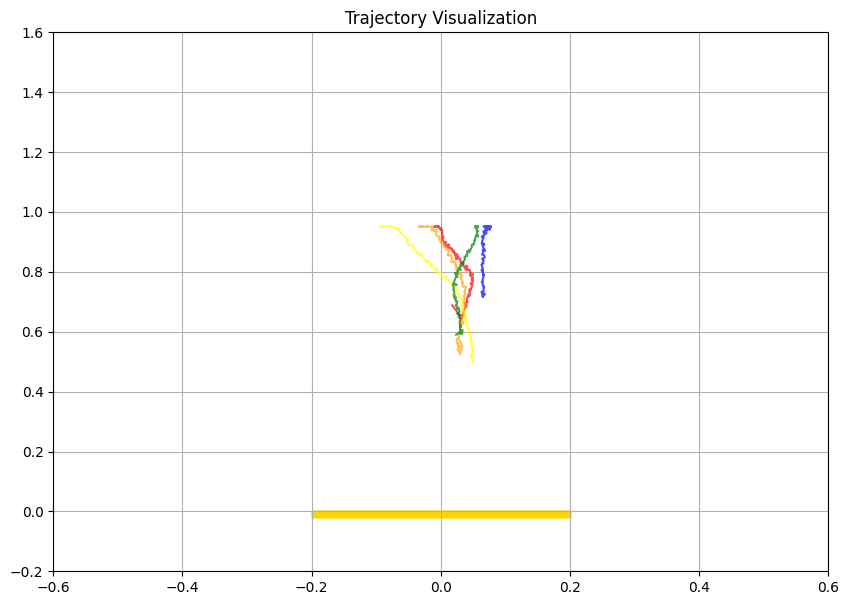

In [17]:
from src.pipelines.eval import evaluate_open_loop_diffusion
from src.diffusion import scheduler_map
noise_scheduler = scheduler_map[args.scheduler](args.num_train_timesteps)
evaluate_open_loop_diffusion(
    env=env,
    model=model,
    noise_scheduler=noise_scheduler,
    stats=minari_dataset_stats,
    input_dim=input_dim,
    args=args,
    logger=None
)

In [ ]:
from src.pipelines.eval import evaluate_policy_mpc
from src.pipelines.sampling import generate_diffusion_trajectory

goal_obs = torch.tensor([0, 0, 0, 0, 0, 0, 1, 1], dtype=torch.float32)
diffusion_planner = lambda cond_dict: generate_diffusion_trajectory(
    model=model,
    noise_scheduler=noise_scheduler,
    stats=minari_dataset_stats,
    args=args,
    input_dim=input_dim,
    condition=cond_dict,
)
model_rewards = evaluate_policy_mpc(
    env=env,
    planner_fn=diffusion_planner,
    num_episodes=10,
    replan_freq=1,
    render=False,
    max_episode_length=300,
    condition_type="start_obs_goal",
    goal_obs=goal_obs,
)
env.close()


--- Starting MPC Evaluation (Condition Type: start_obs) and Replan Frequency: 1 ---
Episode 1/10 finished. Total Reward: -275.42
Episode 2/10 finished. Total Reward: -270.24
Episode 3/10 finished. Total Reward: 90.55
Episode 4/10 finished. Total Reward: -278.88
Episode 5/10 finished. Total Reward: -118.87
Episode 6/10 finished. Total Reward: -286.27
Episode 7/10 finished. Total Reward: -289.41
